In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
def wrap_angle(a):
    return np.arctan2(np.sin(a), np.cos(a))

In [3]:
df_raw = pd.read_csv('../../../../../Data/Animal_Trajectory_Data/mouse/mouse_straight.csv')
wind_direction = np.pi

In [4]:
# data in cm, convert to meters
df_raw.x /= 100
df_raw.y /= 100

In [5]:
scaling = 1

In [6]:
df_calibrated = df_raw*scaling

In [7]:
# estimate time stamps: data collected at 30 Hz; I digitized at half the display frequency
# so should be 15 Hz.. 
timestamps = np.arange(0, df_calibrated.shape[0]*0.066, 0.066)

In [8]:
df_calibrated['timestamps_sec'] = timestamps

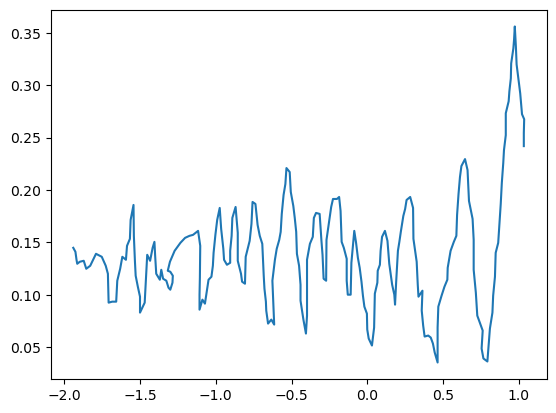

In [9]:
plt.plot(df_calibrated.x.values, df_calibrated.y.values)

In [10]:
from scipy.interpolate import UnivariateSpline

In [11]:
interp_timestamps_sec = np.arange(0, df_calibrated.timestamps_sec.max(), 0.01)

In [12]:
interp_timestamps_sec

array([0.000e+00, 1.000e-02, 2.000e-02, ..., 1.575e+01, 1.576e+01,
       1.577e+01], shape=(1578,))

In [13]:
spline_x = UnivariateSpline(df_calibrated.timestamps_sec, df_calibrated.x, s=1e-4, k=5)  # s=smoothing amount
interp_x = spline_x(interp_timestamps_sec)

spline_y = UnivariateSpline(df_calibrated.timestamps_sec, df_calibrated.y, s=1e-4, k=5)  # s=smoothing amount
interp_y = spline_y(interp_timestamps_sec)

In [14]:
df_calibrated_interp = pd.DataFrame({'timestamps_sec': interp_timestamps_sec,
                                     'x': interp_x,
                                     'y': interp_y})

5.5


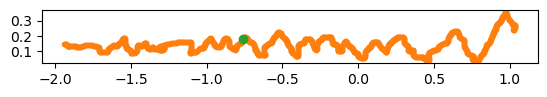

In [15]:
fig = plt.figure()
ax = fig.add_subplot(111)

ax.plot(df_calibrated.x.values, df_calibrated.y.values)
ax.plot(df_calibrated_interp.x.values, df_calibrated_interp.y.values, '.')

tix = 550
ax.plot(df_calibrated_interp.x.values[tix], df_calibrated_interp.y.values[tix], 'o')

print(df_calibrated_interp.timestamps_sec.values[tix])

ax.set_aspect('equal')

In [16]:
import pynumdiff

In [17]:
dt = np.median(np.diff(df_calibrated_interp.timestamps_sec.values))
_, xvel = pynumdiff.savgoldiff(df_calibrated_interp.x, dt, [2, 3, 3])
_, yvel = pynumdiff.savgoldiff(df_calibrated_interp.y, dt, [2, 3, 3])

In [18]:
from braid_analysis import flymath

df_calibrated_interp['xvel'] = xvel
df_calibrated_interp['yvel'] = yvel
df_calibrated_interp['time_relative_to_flash'] = df_calibrated_interp['timestamps_sec'] - df_calibrated_interp.timestamps_sec.values[tix]
df_calibrated_interp['obj_id_unique_event'] = 'shark_a'
df_calibrated_interp['obj_id_unique'] = 'shark_a'
df_calibrated_interp = flymath.assign_course_and_ang_vel_to_dataframe(df_calibrated_interp)

df_calibrated_interp.course_smoothish -= wind_direction + np.pi
df_calibrated_interp.course_smoothish = wrap_angle(df_calibrated_interp.course_smoothish)

In [19]:
np.mean(np.sqrt(df_calibrated_interp.xvel**2 + df_calibrated_interp.yvel**2))

np.float64(0.31704813544728977)

(array([  6.,  22.,  23.,  47.,  61.,  80.,  94., 122., 184., 194., 155.,
        142., 124.,  88.,  62.,  45.,  42.,  30.,  16.]),
 array([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,
          1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.]),
 <BarContainer object of 19 artists>)

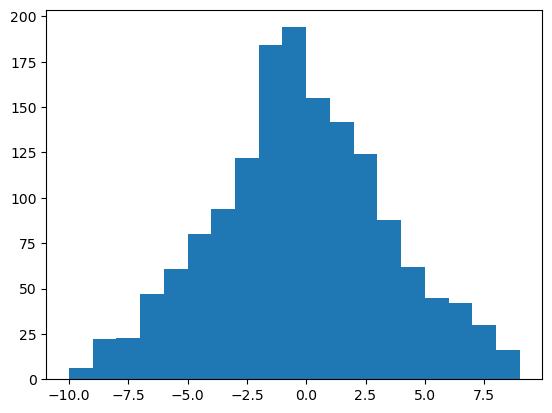

In [20]:
df_calibrated_interp['speed_xy'] = np.sqrt(df_calibrated_interp.xvel**2 + df_calibrated_interp.yvel**2)
plt.hist(df_calibrated_interp.ang_vel_smoothish.values*df_calibrated_interp['speed_xy'], bins=np.arange(-10,10))

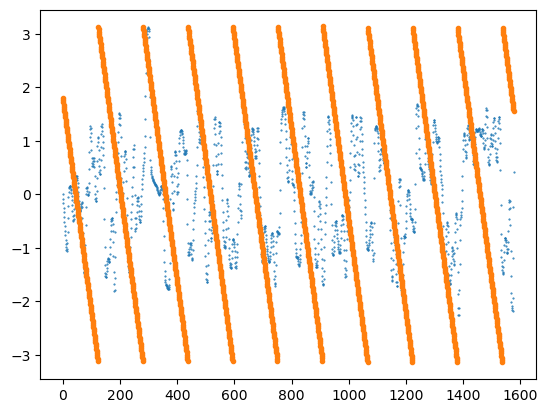

In [21]:
plt.plot(df_calibrated_interp.course_smoothish, '.', markersize=1)

ix = df_calibrated_interp.index.values
slope = -0.04
intercept=1.8
line = slope*ix + intercept

plt.plot(ix, wrap_angle(line), '.')


In [22]:
from align_course_direction_analysis import unifying_algo_analysis as uaa

In [23]:
trajec = df_calibrated_interp

In [24]:
trajec.shape

(1578, 12)

In [25]:
course = trajec.course_smoothish.values
abs_min_ix = tix
abs_max_ix = 1400
min_ix_range = 100
max_ix_range = 200

In [26]:
unifying_algo_fit = uaa.bootstrap_miop_affine_fit(course, 
                                                  abs_min_ix, abs_max_ix, min_ix_range, max_ix_range, 
                                                  npoints = 30, 
                                                  n_bootstraps=10, 
                                                  use_cvx_affine=True, 
                                                  include_translation=True, 
                                                  pis_max = 20, 
                                                  intercept_max = 4,
                                                  huber_M=1.0,
                                                  ignore_large_errors=True,
                                                  error_threshold=2.0,
                                                  large_error_penalty=1.0)

Restricted license - for non-production use only - expires 2027-11-29


/opt/anaconda3/envs/Python311/lib/python3.11/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


In [71]:
# Sort 
sorted_fit = unifying_algo_fit.sort_values('rmse_affine')
best_ix = sorted_fit.index[0]
best_unifying_algo_fit = unifying_algo_fit.iloc[best_ix]

In [72]:
sorted_fit

,min_ix,max_ix,slope,intercept,rotation,major_axis,minor_axis,AM_0_0,AM_0_1,AM_1_0,AM_1_1,tx,ty,rho,mean_residuals,axis_ratio,rmse_affine,shift_ix
7,761,892,-0.081185,2.042861,1.617075,0.874790,0.254810,0.256137,-0.028651,-0.028651,0.873463,0.540112,0.035274,0.836220,0.013473,0.291282,0.516858,800
4,619,726,-0.028610,-5.578473,1.302289,1.018333,0.164416,0.224515,0.218420,0.218420,0.958234,0.429411,-0.169076,0.807820,0.102165,0.161456,0.549745,684
1,1128,1268,-0.049494,6.286939,1.376631,0.750657,-0.076933,-0.046123,0.156681,0.156681,0.719847,0.696413,-0.194679,0.716947,-0.041484,0.102488,0.604898,1143
0,1120,1274,0.021868,-1.885833,1.862448,1.050673,0.072265,0.153156,-0.269446,-0.269446,0.969782,0.524252,0.417559,0.721824,-0.025608,0.068779,0.652614,1236
9,721,917,0.072022,2.086523,1.438512,0.817643,-0.140842,-0.124167,0.125319,0.125319,0.800968,0.566147,-0.057574,0.775156,0.045730,0.172253,0.661782,757
2,598,731,-0.028001,0.246104,-2.043182,0.978582,0.078378,0.264753,0.364746,0.364746,0.792208,0.412490,-0.309226,0.714146,0.087655,0.080094,0.705456,682
8,915,1073,0.077439,-1.965574,1.648661,0.729203,-0.020633,-0.016096,-0.058150,-0.058150,0.724666,0.628354,-0.027172,0.558159,-0.016195,0.028296,0.775012,918
3,764,869,-0.002796,-3.194335,3.944537,49.542631,-2.244735,-22.740457,-25.877741,-25.877741,-24.557439,34.836836,35.922027,0.355441,-0.185358,0.045309,0.921188,816
6,747,903,-0.008132,0.883632,1.731625,0.937961,0.113584,0.134724,-0.130309,-0.130309,0.916821,0.551473,-0.075533,0.291564,-0.125212,0.121096,0.924669,882
5,699,861,0.019452,3.808935,1.523127,0.731187,-0.071899,-0.070075,0.038225,0.038225,0.729363,0.572942,-0.128172,0.449291,0.022639,0.098332,0.986544,774


In [73]:
#best_unifying_algo_fit = unifying_algo_fit.iloc[0]
ix_all, course, linear_fit_angle, affine_fit_angle = uaa.build_miop_and_affine_predictions_from_model(course, best_unifying_algo_fit)

In [74]:
import figurefirst as fifi

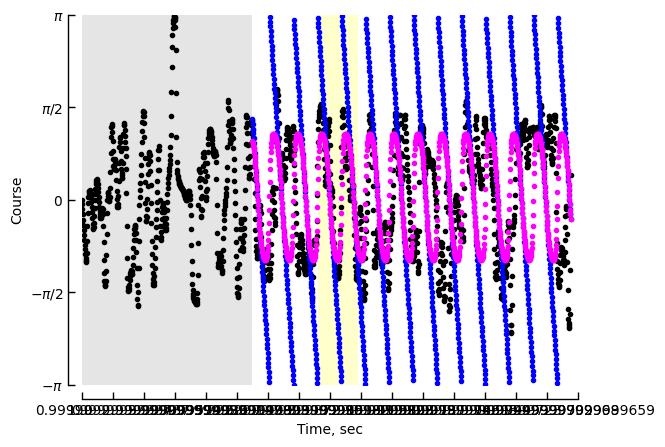

In [75]:
fig = plt.figure()
ax = fig.add_subplot(111)

# shading for before search
ax.fill_betweenx([np.pi, -np.pi], 
                 0, 
                 abs_min_ix, 
                 color='gray', 
                 alpha=0.2, 
                 edgecolor='none', 
                 zorder=-1000)

# add shading for region of interest where fit was applied
min_ix = int(best_unifying_algo_fit.min_ix)
max_ix = int(best_unifying_algo_fit.max_ix)
ax.fill_betweenx([np.pi, -np.pi], 
                 min_ix, 
                 max_ix, 
                 color='yellow', 
                 alpha=0.2, 
                 edgecolor='none', 
                 zorder=-1000)

# plot course, linear fit, and affine fit
ax.plot(ix_all, course, '.', color='black')
ax.plot(ix_all[abs_min_ix:], linear_fit_angle[abs_min_ix:], '.', color='blue')
ax.plot(ix_all[abs_min_ix:], affine_fit_angle[abs_min_ix:], '.', color='magenta')

# Add ticks, labels, etc. 
ax.set_xlim(0, ix_all[-1])
ax.set_ylim(-np.pi, np.pi)

xticks = np.arange( np.min(ix_all), np.max(ix_all) + 50, 100)
dt = np.median(np.diff(df_calibrated_interp.timestamps_sec.values))
xticklabels = dt*xticks
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels)
ax.set_xlabel('Time, sec')

ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax.set_yticklabels(['$-\pi$', '$-\pi/2$','$0$','$\pi/2$','$\pi$',])
ax.set_ylabel('Course')

fifi.mpl_functions.adjust_spines(ax, ['left', 'bottom'])

In [77]:
unifying_algo_fit['abs_slope'] = np.abs(unifying_algo_fit['slope'])
uaa.get_weighted_value(unifying_algo_fit, col='abs_slope')

0.0450760248448486

In [78]:
uaa.get_weighted_value(unifying_algo_fit, col='rho')

0.690067536826992